# 01 - Exploratory Data Analysis
Customer Churn Prediction | Telco Customer Churn Dataset

This notebook loads the raw dataset, cleans it, and performs a full exploratory data analysis (EDA) with business insights after every visualization.

**Sections:** Data Loading -> Data Cleaning -> EDA (10+ visualizations)

In [ ]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from src.preprocessing import DataCleaner
from src.utils import DATA_DIR

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

## Step 1: Data Loading

In [2]:
df_raw = pd.read_csv(DATA_DIR / 'Telco-Customer-Churn.csv')
print('Shape:', df_raw.shape)
print('Columns:', list(df_raw.columns))
df_raw.head(10)

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 2: Data Cleaning
- Convert `TotalCharges` to numeric (it's stored as text due to blank strings)
- Fill missing `TotalCharges` with 0 (these are all tenure=0 customers who haven't been billed)
- Drop duplicate rows
- Drop `customerID` (unique identifier, no predictive value)

In [5]:
cleaner = DataCleaner()
df = cleaner.clean(DATA_DIR / 'Telco-Customer-Churn.csv')
print('Duplicates removed:', cleaner.n_duplicates_removed_)
print('Missing values filled:', cleaner.n_missing_filled_)
print('Final shape:', df.shape)
df.head()

2026-07-13 07:02:35 | INFO     | src.preprocessing | Loaded dataset with shape (7043, 21)


2026-07-13 07:02:35 | INFO     | src.preprocessing | Converted TotalCharges to numeric (errors coerced to NaN).


2026-07-13 07:02:35 | INFO     | src.preprocessing | Filled 11 missing TotalCharges values with 0 (tenure=0 customers).


2026-07-13 07:02:35 | INFO     | src.preprocessing | Removed 0 duplicate rows.


2026-07-13 07:02:35 | INFO     | src.preprocessing | Cleaning complete. Final shape: (7043, 20)


Duplicates removed: 0
Missing values filled: 11
Final shape: (7043, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Step 3: Exploratory Data Analysis

### 3.1 Target Distribution

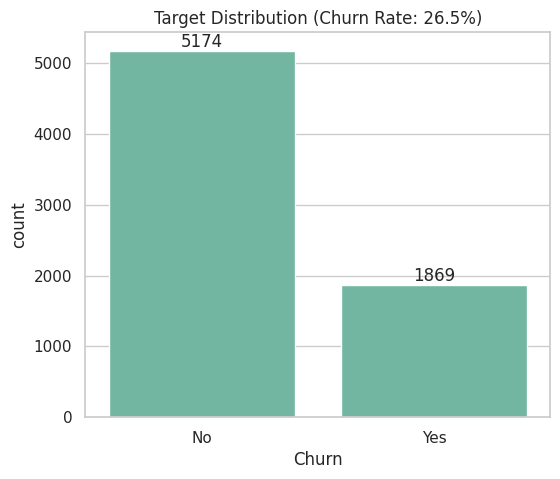

INSIGHT: Overall churn rate is 26.5%. The dataset is moderately imbalanced, so accuracy alone would be a misleading metric.


In [6]:
churn_rate = (df['Churn'] == 'Yes').mean() * 100
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=df, x='Churn', ax=ax)
ax.set_title(f'Target Distribution (Churn Rate: {churn_rate:.1f}%)')
for c in ax.containers: ax.bar_label(c)
plt.show()
print(f'INSIGHT: Overall churn rate is {churn_rate:.1f}%. The dataset is moderately imbalanced, so accuracy alone would be a misleading metric.')

### 3.2 Gender vs Churn

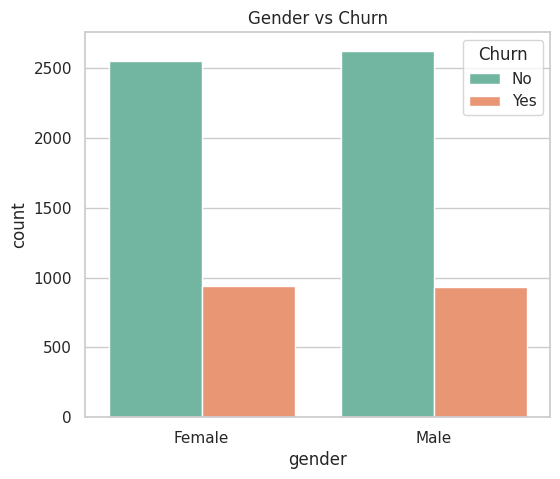

INSIGHT: Churn rate is nearly identical across genders -- gender is unlikely to be a strong standalone predictor.


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.countplot(data=df, x='gender', hue='Churn', ax=ax)
ax.set_title('Gender vs Churn')
plt.show()
print('INSIGHT: Churn rate is nearly identical across genders -- gender is unlikely to be a strong standalone predictor.')

### 3.3 Contract Type vs Churn

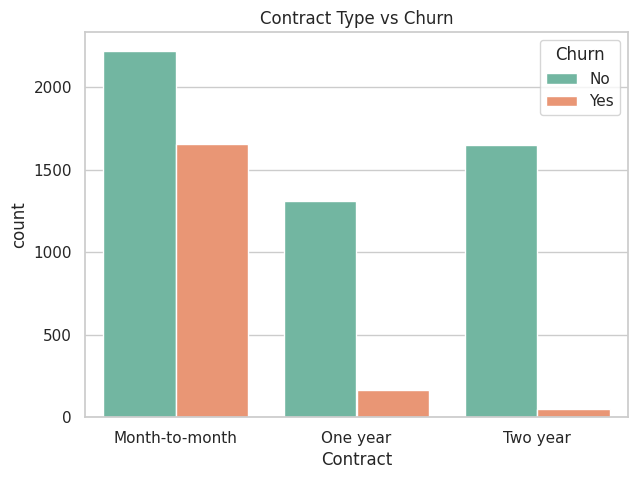

INSIGHT: Month-to-month customers churn at 42.7%, far higher than one/two-year contract holders. Contract length is one of the strongest churn drivers.


In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='Contract', hue='Churn', ax=ax)
ax.set_title('Contract Type vs Churn')
plt.show()
mtm = (df[df['Contract'] == 'Month-to-month']['Churn'] == 'Yes').mean() * 100
print(f'INSIGHT: Month-to-month customers churn at {mtm:.1f}%, far higher than one/two-year contract holders. Contract length is one of the strongest churn drivers.')

### 3.4 Internet Service vs Churn

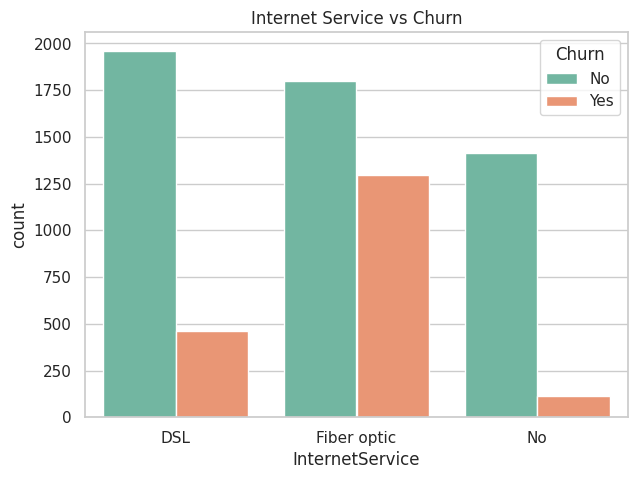

INSIGHT: Fiber optic customers churn at 41.9%, notably higher than DSL.


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', ax=ax)
ax.set_title('Internet Service vs Churn')
plt.show()
fiber = (df[df['InternetService'] == 'Fiber optic']['Churn'] == 'Yes').mean() * 100
print(f'INSIGHT: Fiber optic customers churn at {fiber:.1f}%, notably higher than DSL.')

### 3.5 Payment Method vs Churn

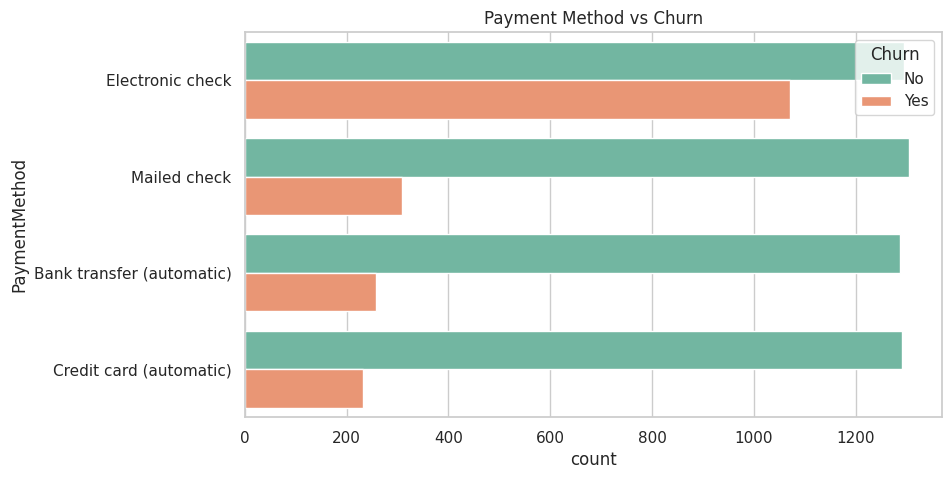

INSIGHT: Electronic check users churn at 45.3%, the highest of all payment methods.


In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.countplot(data=df, y='PaymentMethod', hue='Churn', ax=ax)
ax.set_title('Payment Method vs Churn')
plt.show()
echk = (df[df['PaymentMethod'] == 'Electronic check']['Churn'] == 'Yes').mean() * 100
print(f'INSIGHT: Electronic check users churn at {echk:.1f}%, the highest of all payment methods.')

### 3.6 Monthly Charges & Tenure Distributions

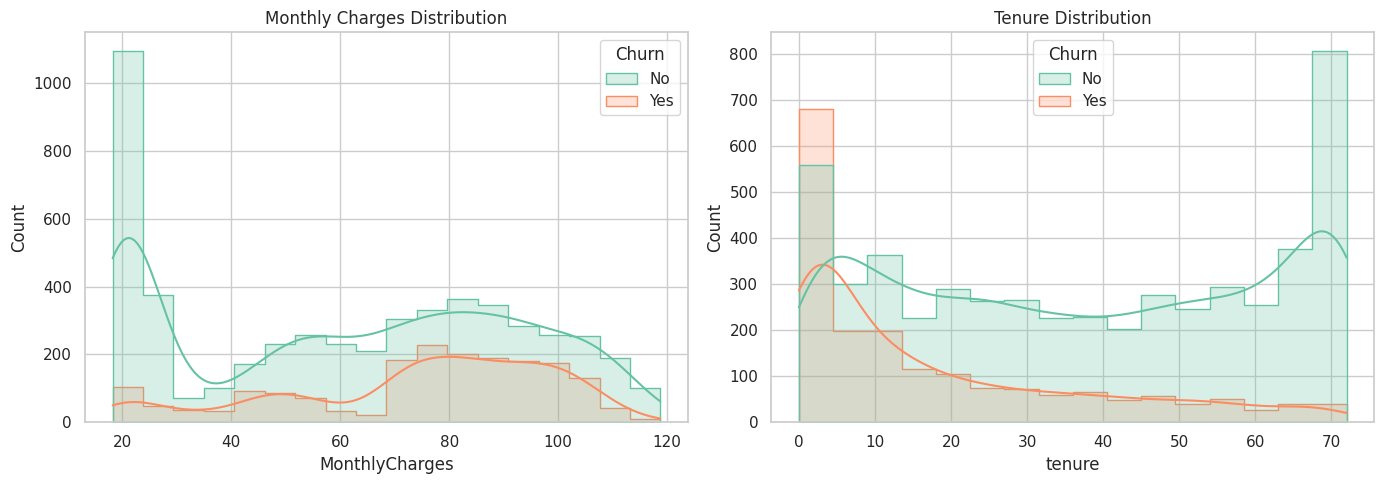

INSIGHT: Churned customers cluster at higher monthly charges and low tenure -- new, price-sensitive customers are the highest churn risk.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, ax=axes[0], element='step')
axes[0].set_title('Monthly Charges Distribution')
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, ax=axes[1], element='step')
axes[1].set_title('Tenure Distribution')
plt.tight_layout(); plt.show()
print('INSIGHT: Churned customers cluster at higher monthly charges and low tenure -- new, price-sensitive customers are the highest churn risk.')

### 3.7 Correlation Heatmap

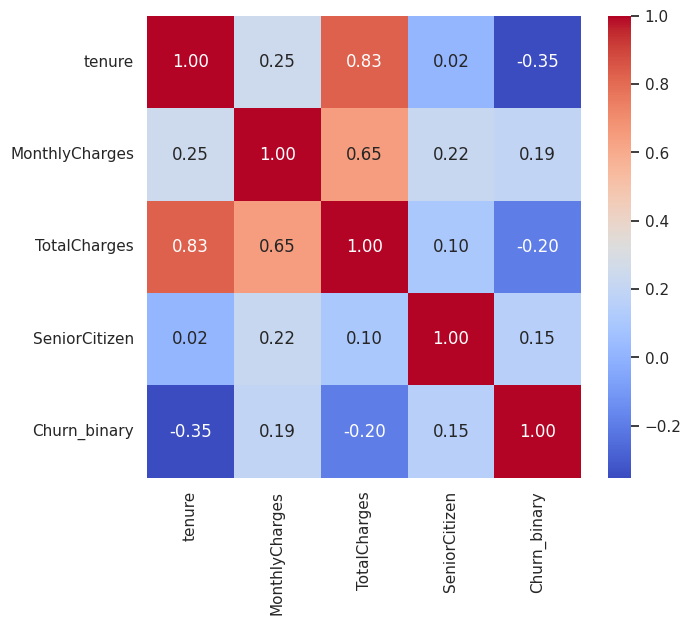

INSIGHT: Tenure correlates negatively with churn; MonthlyCharges correlates positively.


In [12]:
numeric_df = df.copy()
numeric_df['Churn_binary'] = (numeric_df['Churn'] == 'Yes').astype(int)
numeric_df['SeniorCitizen'] = numeric_df['SeniorCitizen'].astype(int)
cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(numeric_df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.show()
print('INSIGHT: Tenure correlates negatively with churn; MonthlyCharges correlates positively.')

### 3.8 Pairplot

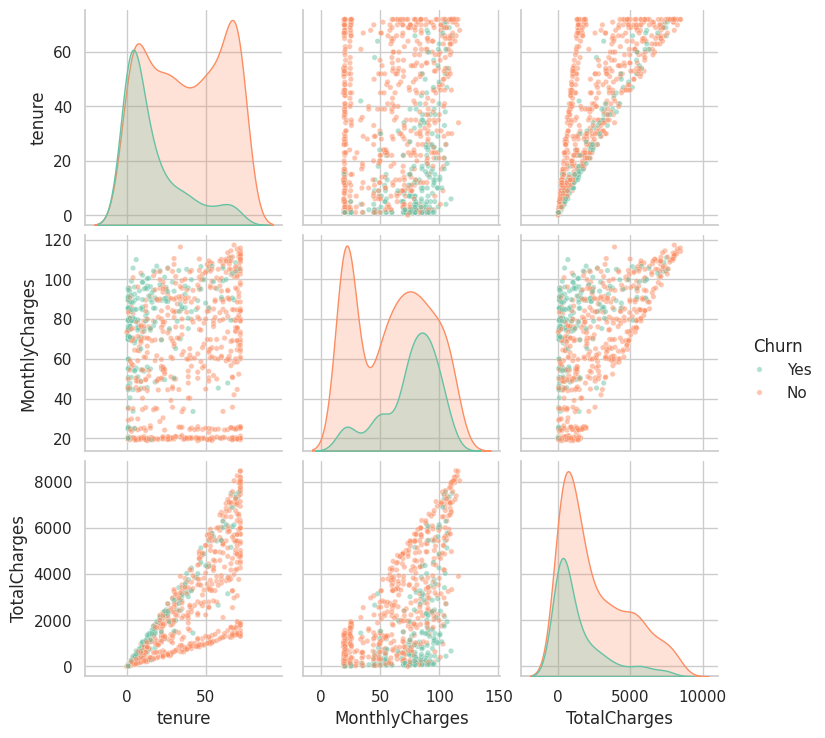

In [13]:
sample = numeric_df.sample(min(800, len(numeric_df)), random_state=42)
sns.pairplot(sample[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],
             hue='Churn', diag_kind='kde', plot_kws={'alpha': 0.5, 's': 15})
plt.show()

### 3.9 Categorical Countplots (Partner, Dependents, PaperlessBilling, SeniorCitizen)

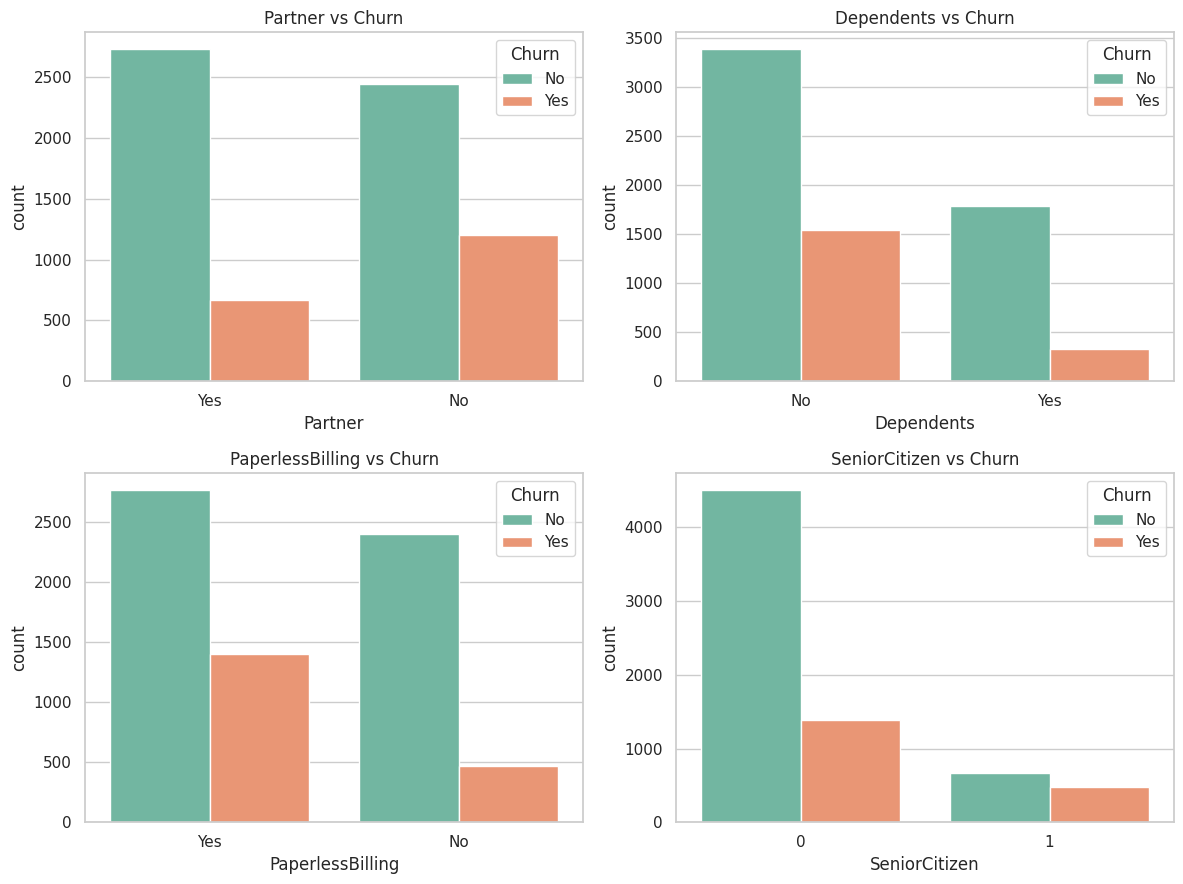

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, c in zip(axes.ravel(), ['Partner', 'Dependents', 'PaperlessBilling', 'SeniorCitizen']):
    sns.countplot(data=df, x=c, hue='Churn', ax=ax)
    ax.set_title(f'{c} vs Churn')
plt.tight_layout(); plt.show()

### 3.10 Outlier Detection (Boxplots + IQR)

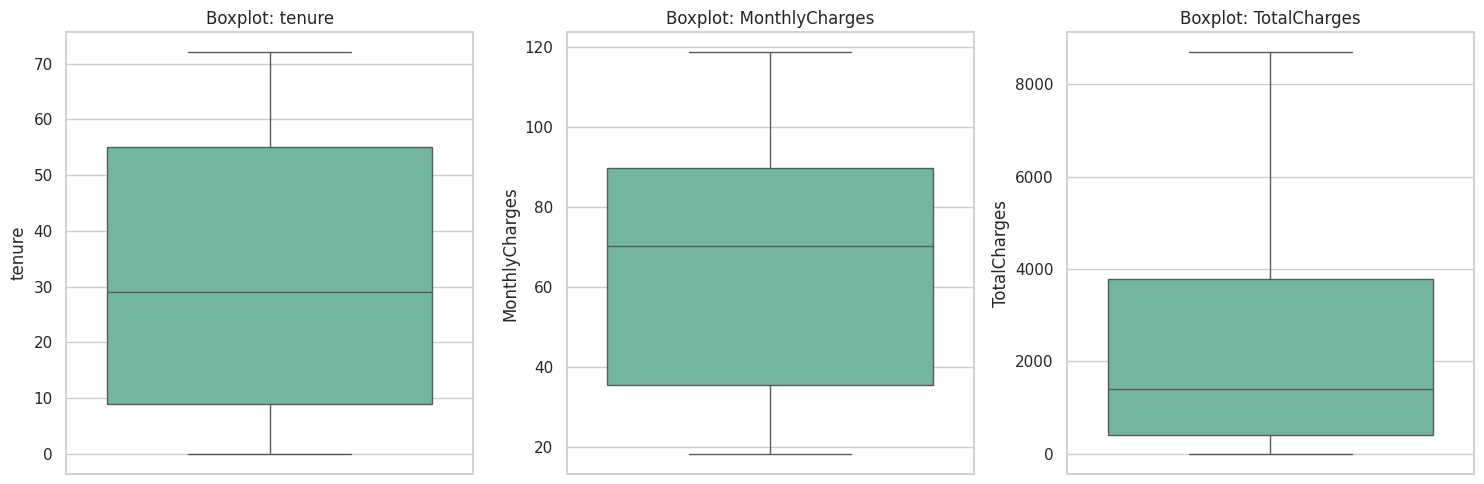

tenure: 0 outliers (bounds: [-60.0, 124.0])
MonthlyCharges: 0 outliers (bounds: [-46.0, 171.4])
TotalCharges: 0 outliers (bounds: [-4683.5, 8868.7])


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, c in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.boxplot(data=df, y=c, ax=ax)
    ax.set_title(f'Boxplot: {c}')
plt.tight_layout(); plt.show()

for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col}: {n_out} outliers (bounds: [{lower:.1f}, {upper:.1f}])')

## Summary of Key EDA Insights
1. Overall churn rate ≈ 26.5% (moderately imbalanced target)
2. Month-to-month contracts churn far more than annual contracts
3. Fiber optic internet customers churn more than DSL customers
4. Electronic check payers churn the most; automatic payments retain customers better
5. Low-tenure, high-monthly-charge customers are the highest risk segment
6. Gender has little to no effect on churn
7. No extreme outliers were found in the numeric features

Proceed to **02_Preprocessing.ipynb** for feature engineering.